## Imports

In [1]:
import os
import glob
import time
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay,
    roc_curve, auc, roc_auc_score,
    precision_recall_curve, average_precision_score
)

import matplotlib.pyplot as plt
import seaborn as sns

## Path Setup

In [2]:
#from google.colab import drive
#drive.mount('/content/drive')

In [3]:
#BASE_PATH = "/content/drive/MyDrive/Spring 2026/IDS_Project"
BASE_PATH = "/home/phillip/IDS_Project"
#BASE_PATH = "C:/Users/phill/Desktop/IDS_Project"

RAW_DATA = os.path.join(BASE_PATH, "raw_data")
ML_DATA = os.path.join(RAW_DATA, "MachineLearningCVE")

print("BASE_PATH:", BASE_PATH)
print("ML_DATA:", ML_DATA)

BASE_PATH: /home/phillip/IDS_Project
ML_DATA: /home/phillip/IDS_Project/raw_data/MachineLearningCVE


In [4]:
print(os.listdir(ML_DATA)[:10])

['Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv', 'Friday-WorkingHours-Morning.pcap_ISCX.csv', 'Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv:Zone.Identifier', 'Wednesday-workingHours.pcap_ISCX.csv:Zone.Identifier', 'Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv:Zone.Identifier', 'Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv:Zone.Identifier', 'Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv:Zone.Identifier', 'Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv', 'Tuesday-WorkingHours.pcap_ISCX.csv:Zone.Identifier', 'Tuesday-WorkingHours.pcap_ISCX.csv']


In [5]:

all_files = glob.glob(os.path.join(ML_DATA, "*.csv"))
print("Number of CSV files found:", len(all_files))

df_list = []

for file in sorted(all_files):
    print("Loading:", os.path.basename(file))
    temp_df = pd.read_csv(file, low_memory=False)
    df_list.append(temp_df)

df = pd.concat(df_list, ignore_index=True)

print("Combined dataset shape:", df.shape)
df.head()

Number of CSV files found: 8
Loading: Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv
Loading: Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv
Loading: Friday-WorkingHours-Morning.pcap_ISCX.csv
Loading: Monday-WorkingHours.pcap_ISCX.csv
Loading: Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv
Loading: Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv
Loading: Tuesday-WorkingHours.pcap_ISCX.csv
Loading: Wednesday-workingHours.pcap_ISCX.csv
Combined dataset shape: (2830743, 79)


,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,54865,3,2,0,12,0,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
1,55054,109,1,1,6,6,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
2,55055,52,1,1,6,6,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
3,46236,34,1,1,6,6,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
4,54863,3,2,0,12,0,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN


### Clean Data

In [6]:
# Clean column names
df.columns = df.columns.str.strip()

# Replace inf with NaN
df.replace([np.inf, -np.inf], np.nan, inplace=True)

# Drop missing values
df.dropna(inplace=True)

print("Shape after cleaning:", df.shape)
print(df["Label"].value_counts())

Shape after cleaning: (2827876, 79)
Label
BENIGN                        2271320
DoS Hulk                       230124
PortScan                       158804
DDoS                           128025
DoS GoldenEye                   10293
FTP-Patator                      7935
SSH-Patator                      5897
DoS slowloris                    5796
DoS Slowhttptest                 5499
Bot                              1956
Web Attack � Brute Force         1507
Web Attack � XSS                  652
Infiltration                       36
Web Attack � Sql Injection         21
Heartbleed                         11
Name: count, dtype: int64


### Convert to Binary
The original attack categories are converted into binary classes:
- `0` for BENIGN
- `1` for ATTACK

In [7]:
df["Label"] = df["Label"].apply(lambda x: 0 if x == "BENIGN" else 1)

print(df["Label"].value_counts())

Label
0    2271320
1     556556
Name: count, dtype: int64


### Separate Features and Target
The dataset is divided into input features `X` and target labels `y`.

In [8]:
X = df.drop("Label", axis=1)
y = df["Label"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (2827876, 78)
y shape: (2827876,)


### Remove Duplicate Rows
Duplicate rows are removed to reduce redundancy and prevent the model from learning repeated samples.

In [9]:
before_dups = df.shape[0]
df = df.drop_duplicates()
after_dups = df.shape[0]

print("Rows before duplicate removal:", before_dups)
print("Rows after duplicate removal:", after_dups)
print("Duplicates removed:", before_dups - after_dups)

Rows before duplicate removal: 2827876
Rows after duplicate removal: 2520798
Duplicates removed: 307078


### Train-Test Split
The cleaned dataset is split into training and testing sets. Stratified sampling is used so the class distribution remains consistent across both sets.

In [10]:
X = df.drop("Label", axis=1)
y = df["Label"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(X_train.shape, X_test.shape)

(2016638, 78) (504160, 78)


In [11]:
print("Train label distribution:")
print(y_train.value_counts(normalize=True))

print("\nTest label distribution:")
print(y_test.value_counts(normalize=True))

Train label distribution:
Label
0    0.831109
1    0.168891
Name: proportion, dtype: float64

Test label distribution:
Label
0    0.831109
1    0.168891
Name: proportion, dtype: float64


## Plotting Functions

In [12]:
#Confusion Matrix
def plot_confusion(y_true, y_pred, model_name):
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["BENIGN", "ATTACK"])
    disp.plot(cmap="Blues")
    plt.title(f"{model_name} - Confusion Matrix")
    plt.show()

In [13]:
#ROC Curve
def plot_roc(y_true, y_scores, model_name):
    fpr, tpr, _ = roc_curve(y_true, y_scores)
    roc_auc = auc(fpr, tpr)

    plt.figure(figsize=(6, 4))
    plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.4f}")
    plt.plot([0, 1], [0, 1], linestyle="--")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"{model_name} - ROC Curve")
    plt.legend()
    plt.grid(True)
    plt.show()

In [14]:
#Precision Recall Curve
def plot_pr_curve(y_true, y_scores, model_name):
    precision, recall, _ = precision_recall_curve(y_true, y_scores)
    ap = average_precision_score(y_true, y_scores)

    plt.figure(figsize=(6, 4))
    plt.plot(recall, precision, label=f"AP = {ap:.4f}")
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title(f"{model_name} - Precision-Recall Curve")
    plt.legend()
    plt.grid(True)
    plt.show()

## Logistic Regression

### Feature Scaling
Standardization is applied to the feature values so that models such as Logistic Regression can train more effectively. The scaler is fit only on the training data and then applied to both training and testing sets.

In [15]:
results = []

In [16]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_log = scaler.fit_transform(X_train)
X_test_log = scaler.transform(X_test)

print("X_train_log shape:", X_train_log.shape)
print("X_test_log shape:", X_test_log.shape)

X_train_log shape: (2016638, 78)
X_test_log shape: (504160, 78)


### Model

In [17]:
log_model = LogisticRegression(max_iter=1000)

log_start = time.time()
log_model.fit(X_train_log, y_train)
log_end = time.time()

y_pred_log = log_model.predict(X_test_log)
y_score_log = log_model.predict_proba(X_test_log)[:, 1]

### Metrics

In [18]:
# Accuracy, Precision, Recall, F1, Training Time metrics
log_accuracy = accuracy_score(y_test, y_pred_log)
log_precision = precision_score(y_test, y_pred_log)
log_recall = recall_score(y_test, y_pred_log)
log_f1 = f1_score(y_test, y_pred_log)
log_time = log_end - log_start

print("Accuracy:", log_accuracy)
print("Precision:", log_precision)
print("Recall:", log_recall)
print("F1:", log_f1)
print("Training Time:", log_time)

Accuracy: 0.9572734846080609
Precision: 0.8822122606929539
Recall: 0.8621224221355757
F1: 0.872051652143956
Training Time: 147.5067389011383


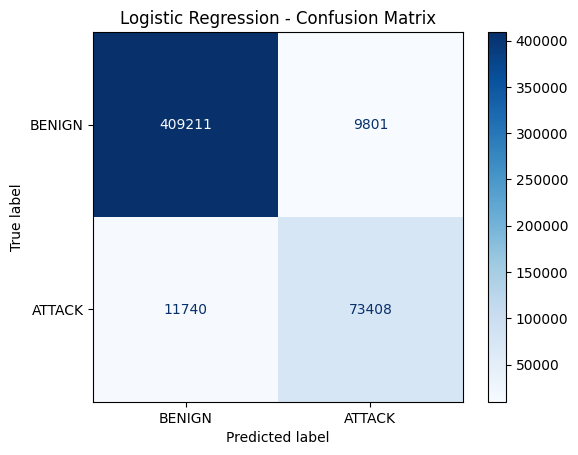

In [19]:
# Logisitic Regression Confusion Matrix
cm = confusion_matrix(y_test, y_pred_log)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["BENIGN", "ATTACK"])
disp.plot(cmap="Blues")
plt.title("Logistic Regression - Confusion Matrix")
plt.show()

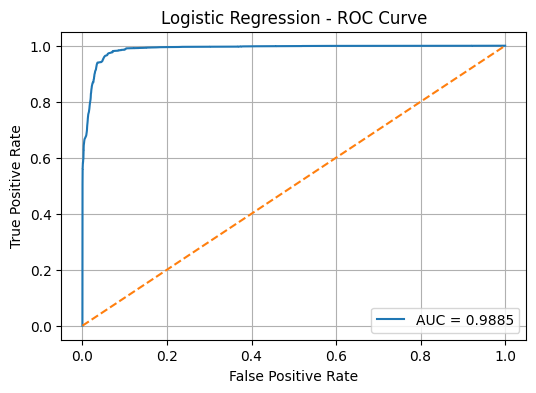

In [20]:
# Logisitic Regression ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_score_log)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6, 4))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.4f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Logistic Regression - ROC Curve")
plt.legend()
plt.grid(True)
plt.show()

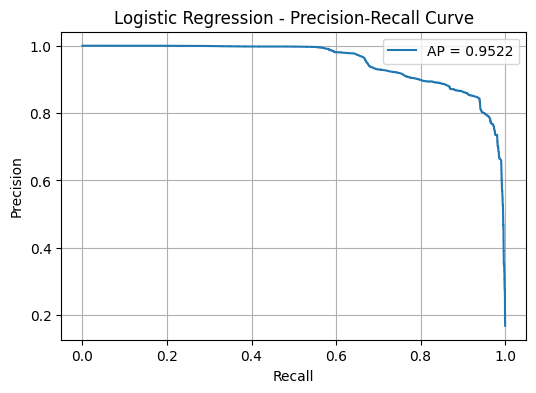

In [21]:
# Precision Recall Curve
precisions, recalls, _ = precision_recall_curve(y_test, y_score_log)
ap = average_precision_score(y_test, y_score_log)

plt.figure(figsize=(6, 4))
plt.plot(recalls, precisions, label=f"AP = {ap:.4f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Logistic Regression - Precision-Recall Curve")
plt.legend()
plt.grid(True)
plt.show()

In [22]:
results.append({
    "Model": "Logistic Regression",
    "Accuracy": log_accuracy,
    "Precision": log_precision,
    "Recall": log_recall,
    "F1-Score": log_f1,
    "ROC-AUC": roc_auc,
    "PR-AUC": ap,
    "Training Time": log_time
})

## Random Forest

In [23]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf_start = time.time()
rf_model.fit(X_train, y_train)
rf_end = time.time()

In [24]:
y_pred_rf = rf_model.predict(X_test)
y_score_rf = rf_model.predict_proba(X_test)[:, 1]

In [25]:
#Accuracy, Precision, Recall, F1, Training Time
rf_accuracy = accuracy_score(y_test, y_pred_rf)
rf_precision = precision_score(y_test, y_pred_rf)
rf_recall = recall_score(y_test, y_pred_rf)
rf_f1 = f1_score(y_test, y_pred_rf)
rf_time = rf_end - rf_start

print("Accuracy:", rf_accuracy)
print("Precision:", rf_precision)
print("Recall:", rf_recall)
print("F1:", rf_f1)
print("Training Time:", rf_time)

Accuracy: 0.9985401459854014
Precision: 0.996377663828386
Recall: 0.9949734579790482
F1: 0.9956750658142158
Training Time: 256.47085976600647


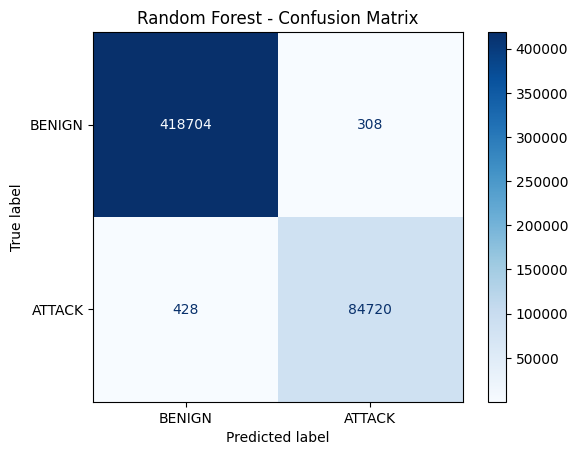

In [26]:
#Confusion Matrix
cm = confusion_matrix(y_test, y_pred_rf)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["BENIGN", "ATTACK"])
disp.plot(cmap="Blues")
plt.title("Random Forest - Confusion Matrix")
plt.show()

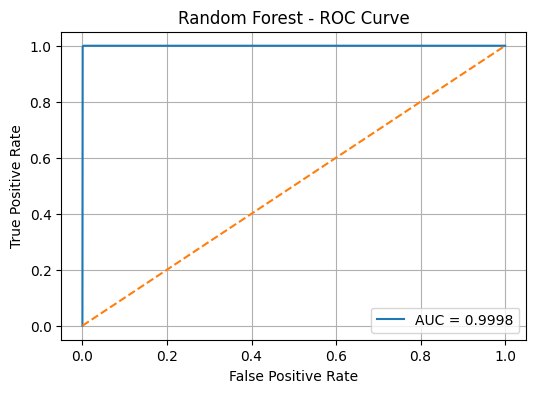

In [27]:
#ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_score_rf)
rf_roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6, 4))
plt.plot(fpr, tpr, label=f"AUC = {rf_roc_auc:.4f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Random Forest - ROC Curve")
plt.legend()
plt.grid(True)
plt.show()

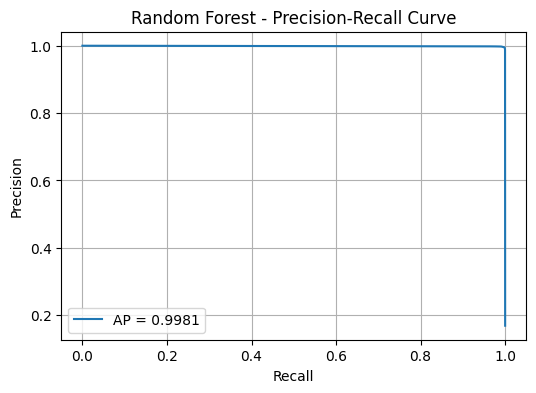

In [28]:
# Precision Recall
precisions, recalls, _ = precision_recall_curve(y_test, y_score_rf)
rf_ap = average_precision_score(y_test, y_score_rf)

plt.figure(figsize=(6, 4))
plt.plot(recalls, precisions, label=f"AP = {rf_ap:.4f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Random Forest - Precision-Recall Curve")
plt.legend()
plt.grid(True)
plt.show()

In [29]:
results.append({
    "Model": "Random Forest",
    "Accuracy": rf_accuracy,
    "Precision": rf_precision,
    "Recall": rf_recall,
    "F1-Score": rf_f1,
    "ROC-AUC": rf_roc_auc,
    "PR-AUC": rf_ap,
    "Training Time": rf_time
})

### Feature Importance

In [30]:
feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": rf_model.feature_importances_
}).sort_values(by="Importance", ascending=False)

feature_importance.head(15)

,Feature,Importance
54,Avg Bwd Segment Size,0.080357
41,Packet Length Std,0.076289
42,Packet Length Variance,0.067827
39,Max Packet Length,0.065158
10,Bwd Packet Length Max,0.051022
13,Bwd Packet Length Std,0.046243
52,Average Packet Size,0.042253
12,Bwd Packet Length Mean,0.031439
5,Total Length of Bwd Packets,0.029725
0,Destination Port,0.028379


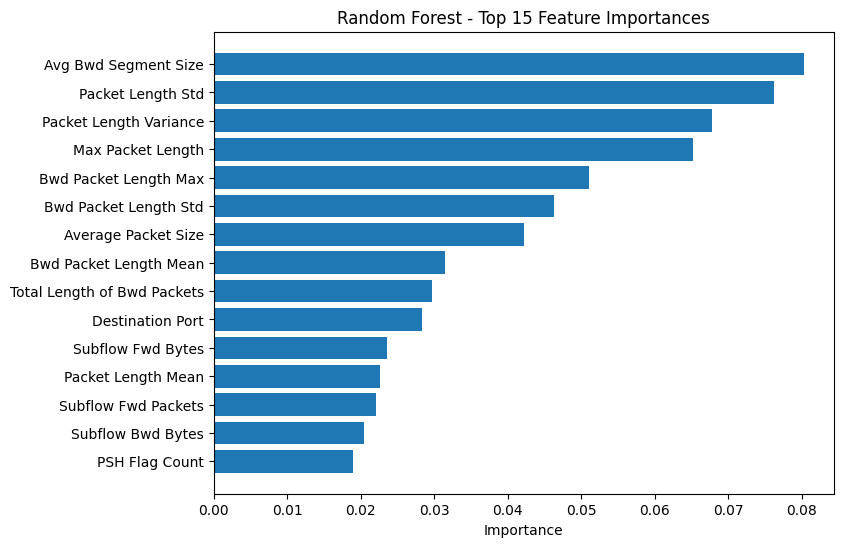

In [31]:
top_features = feature_importance.head(15)

plt.figure(figsize=(8, 6))
plt.barh(top_features["Feature"], top_features["Importance"])
plt.gca().invert_yaxis()
plt.xlabel("Importance")
plt.title("Random Forest - Top 15 Feature Importances")
plt.show()

# Comparison

In [32]:
results_df = pd.DataFrame(results)
results_df.sort_values(by="F1-Score", ascending=False)
results_df.round(4)

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC,PR-AUC,Training Time
0,Logistic Regression,0.9573,0.8822,0.8621,0.8721,0.9885,0.9522,147.5067
1,Random Forest,0.9985,0.9964,0.9950,0.9957,0.9998,0.9981,256.4709


## Deep Learning Model (Neural Network)


In [33]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

I0000 00:00:1776833004.032728    3732 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


### Scale Data for Neural Network

### Feature Scaling for Neural Network
Neural networks usually perform better when the input features are scaled.

In [34]:
# Reuse the scaled data from Logistic Regression
X_train_nn = X_train_log
X_test_nn = X_test_log

print("X_train_nn shape:", X_train_nn.shape)
print("X_test_nn shape:", X_test_nn.shape)

X_train_nn shape: (2016638, 78)
X_test_nn shape: (504160, 78)


### Build and Train Neural Network

### Build and Train Neural Network
A simple feedforward neural network is used as the first deep learning baseline.

In [35]:
tf.random.set_seed(42)

nn_model = Sequential([
    Dense(64, activation="relu", input_shape=(X_train_nn.shape[1],)),
    Dropout(0.3),
    Dense(32, activation="relu"),
    Dropout(0.2),
    Dense(1, activation="sigmoid")
])

nn_model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

nn_start = time.time()

history = nn_model.fit(
    X_train_nn,
    y_train,
    validation_split=0.2,
    epochs=15,
    batch_size=1024,
    callbacks=[early_stop],
    verbose=1
)

nn_end = time.time()

/home/phillip/IDS_Project/venv/lib/python3.12/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
W0000 00:00:1776833007.490050    3732 gpu_device.cc:2365] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


Epoch 1/15


W0000 00:00:1776833009.412868    3732 cpu_allocator_impl.cc:82] Allocation of 503352720 exceeds 10% of free system memory.


1566/1576 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9339 - loss: 0.1625

W0000 00:00:1776833018.788880    3732 cpu_allocator_impl.cc:82] Allocation of 125838336 exceeds 10% of free system memory.


1576/1576 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.9584 - loss: 0.1012 - val_accuracy: 0.9744 - val_loss: 0.0588
Epoch 2/15
1576/1576 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9744 - loss: 0.0592 - val_accuracy: 0.9799 - val_loss: 0.0478
Epoch 3/15
1576/1576 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9776 - loss: 0.0511 - val_accuracy: 0.9806 - val_loss: 0.0433
Epoch 4/15
1576/1576 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9792 - loss: 0.0470 - val_accuracy: 0.9811 - val_loss: 0.0414
Epoch 5/15
1576/1576 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9806 - loss: 0.0442 - val_accuracy: 0.9818 - val_loss: 0.0395
Epoch 6/15
1576/1576 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9815 - loss: 0.0420 - val_accuracy: 0.9831 - val_loss: 0.0360
Epoch 7/15
1576/1576 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9828 - loss: 0.0400 - val_accuracy: 0.9851 - val_loss: 0.0338
Epoch 8/15
1576/1576 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9829 - loss: 0.0391 - val_accura

### Neural Network Predictions and Metrics

### Neural Network Predictions and Metrics
This section computes the same evaluation metrics used for the machine learning models.

In [36]:
y_score_nn = nn_model.predict(X_test_nn).ravel()
y_pred_nn = (y_score_nn >= 0.5).astype(int)

nn_accuracy = accuracy_score(y_test, y_pred_nn)
nn_precision = precision_score(y_test, y_pred_nn)
nn_recall = recall_score(y_test, y_pred_nn)
nn_f1 = f1_score(y_test, y_pred_nn)
nn_time = nn_end - nn_start

print("Accuracy:", nn_accuracy)
print("Precision:", nn_precision)
print("Recall:", nn_recall)
print("F1:", nn_f1)
print("Training Time:", nn_time)

  150/15755 ━━━━━━━━━━━━━━━━━━━━ 10s 673us/step

W0000 00:00:1776833097.476539    3732 cpu_allocator_impl.cc:82] Allocation of 157297920 exceeds 10% of free system memory.


15755/15755 ━━━━━━━━━━━━━━━━━━━━ 11s 666us/step
Accuracy: 0.9893525864804824
Precision: 0.9847372770135615
Recall: 0.9517076149762767
F1: 0.9679407548972766
Training Time: 89.72755742073059


### Neural Network Evaluation Plots

### Neural Network Evaluation Plots
The confusion matrix, ROC curve, and Precision-Recall curve are shown below.

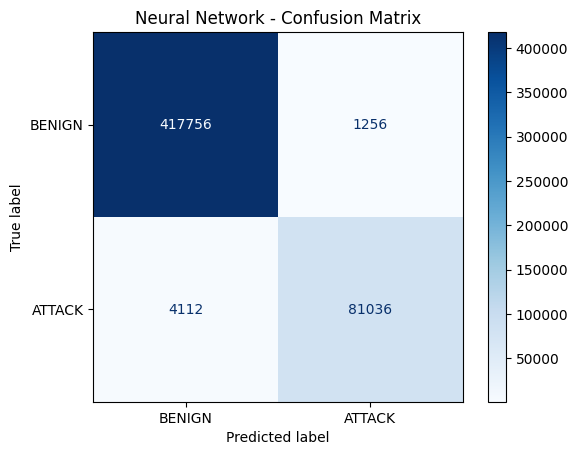

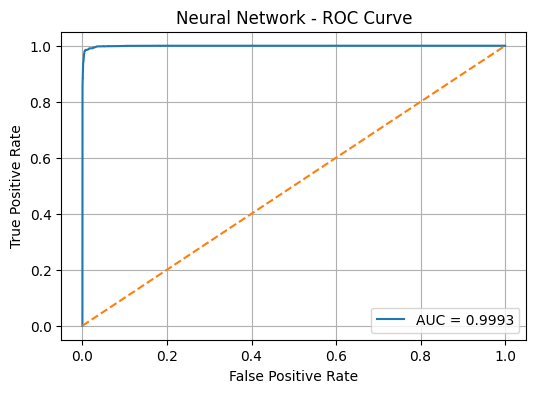

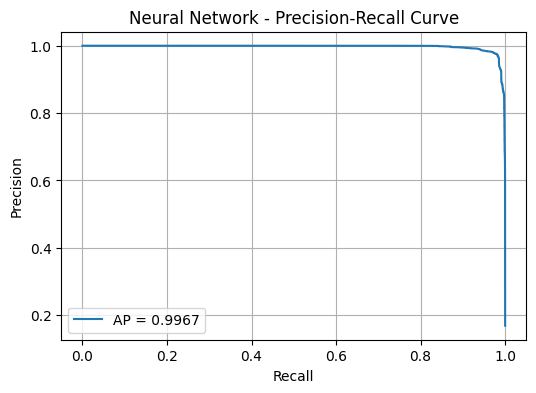

In [37]:
plot_confusion(y_test, y_pred_nn, "Neural Network")
plot_roc(y_test, y_score_nn, "Neural Network")
plot_pr_curve(y_test, y_score_nn, "Neural Network")

### Neural Network Training Curves

### Neural Network Training Curves
These plots help show whether the model is learning well and whether it starts to overfit.

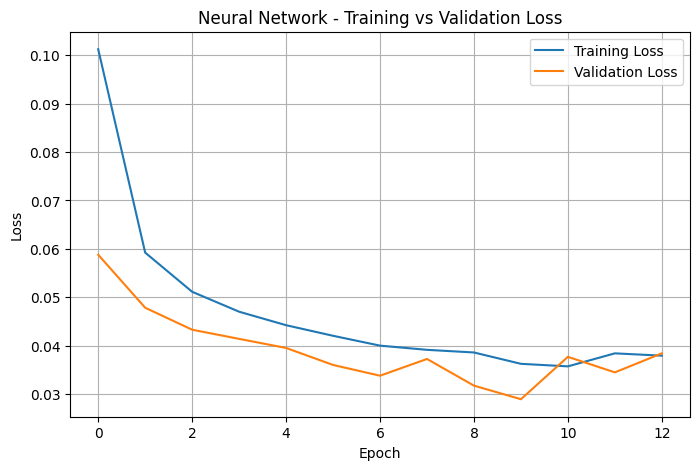

In [38]:
plt.figure(figsize=(8, 5))
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Neural Network - Training vs Validation Loss")
plt.legend()
plt.grid(True)
plt.show()

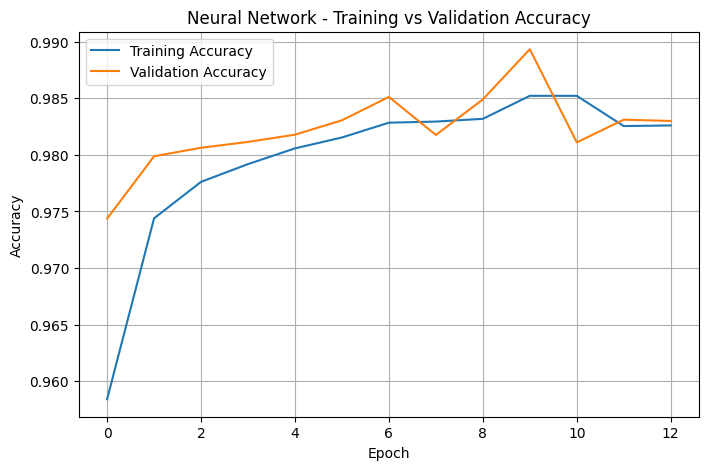

In [39]:
plt.figure(figsize=(8, 5))
plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Neural Network - Training vs Validation Accuracy")
plt.legend()
plt.grid(True)
plt.show()

### Add Neural Network Results to Comparison Table

### Save Neural Network Results
The neural network results are added to the comparison table used across all models.

In [40]:
nn_fpr, nn_tpr, _ = roc_curve(y_test, y_score_nn)
nn_roc_auc = auc(nn_fpr, nn_tpr)
nn_ap = average_precision_score(y_test, y_score_nn)

results.append({
    "Model": "Neural Network",
    "Accuracy": nn_accuracy,
    "Precision": nn_precision,
    "Recall": nn_recall,
    "F1-Score": nn_f1,
    "ROC-AUC": nn_roc_auc,
    "PR-AUC": nn_ap,
    "Training Time": nn_time
})

## Explainability with SHAP

## Explainability with SHAP
To make the intrusion detection system more interpretable, SHAP is used to explain which features influenced model predictions.

This adds an innovative part to the project by showing not only whether the model detects attacks, but also why it makes those predictions.

In [41]:
#!pip install shap -q
import shap

/home/phillip/IDS_Project/venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [42]:
# Use a smaller sample for SHAP to avoid memory issues
X_shap_sample = X_test.sample(n=min(1000, len(X_test)), random_state=42)

explainer = shap.TreeExplainer(rf_model)
shap_values = explainer.shap_values(X_shap_sample)

In [43]:
# For binary classification, use the attack class if shap returns a list
if isinstance(shap_values, list):
    shap_values_to_plot = shap_values[1]
else:
    shap_values_to_plot = shap_values

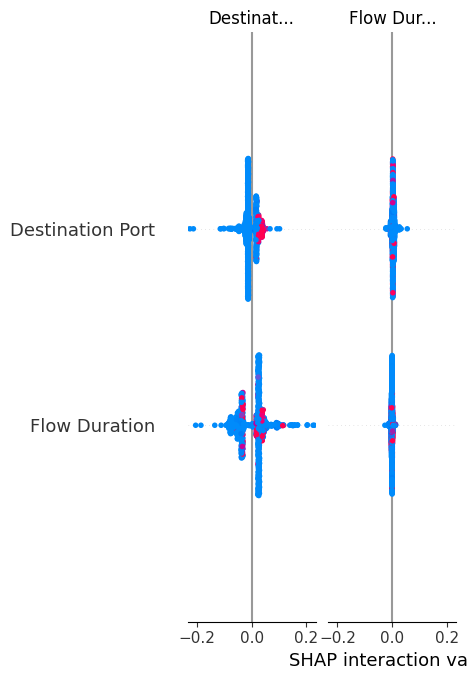

In [44]:
shap.summary_plot(shap_values_to_plot, X_shap_sample, plot_type="bar")

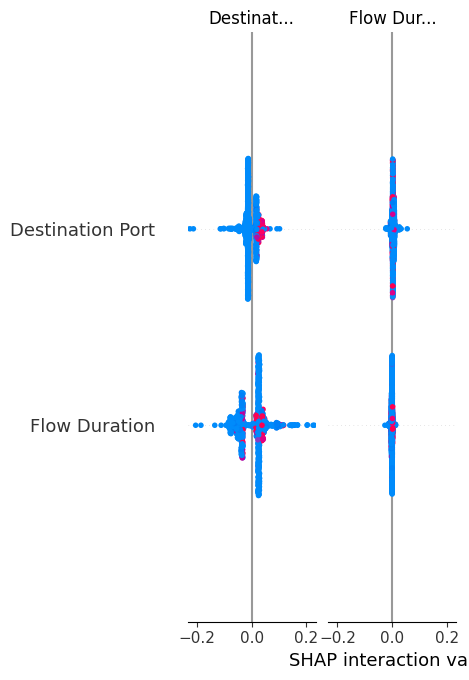

In [45]:
shap.summary_plot(shap_values_to_plot, X_shap_sample)

## Model Comparison
This table compares all trained models side by side.

In [46]:
results_df = pd.DataFrame(results)
results_df = results_df.sort_values(by="F1-Score", ascending=False)
results_df.round(4)

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC,PR-AUC,Training Time
1,Random Forest,0.9985,0.9964,0.9950,0.9957,0.9998,0.9981,256.4709
2,Neural Network,0.9894,0.9847,0.9517,0.9679,0.9993,0.9967,89.7276
0,Logistic Regression,0.9573,0.8822,0.8621,0.8721,0.9885,0.9522,147.5067


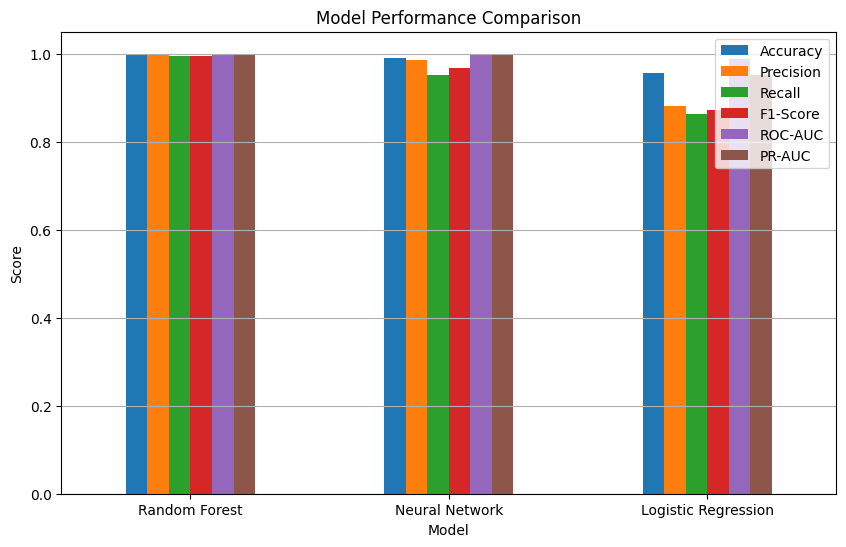

In [47]:
results_df_plot = results_df.set_index("Model")

results_df_plot[["Accuracy", "Precision", "Recall", "F1-Score", "ROC-AUC", "PR-AUC"]].plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.ylim(0, 1.05)
plt.xticks(rotation=0)
plt.grid(axis="y")
plt.show()

## Alert Simulation and What-If Attack Testing
This section simulates how the trained intrusion detection model could be used in practice.

Instead of only reporting accuracy metrics, the model predictions are converted into readable alert outputs.  
This section also introduces a simple what-if testing function, where feature values can be changed manually to see how the model reacts.

This helps make the project more practical and more interactive.

In [48]:
# Choose the model used for alert simulation
# Random Forest is a good choice because it performs well and supports probability scores.
alert_model = rf_model

print("Alert simulation model selected: Random Forest")

Alert simulation model selected: Random Forest


### Create a Prediction DataFrame
This combines test samples, true labels, predicted labels, and model confidence scores into one table.

In [49]:
# Copy test features so we can inspect predictions alongside the original values
alerts_df = X_test.copy()

alerts_df["True_Label"] = y_test.values
alerts_df["Predicted_Label"] = y_pred_rf
alerts_df["Attack_Probability"] = y_score_rf

alerts_df["True_Label_Name"] = alerts_df["True_Label"].map({0: "BENIGN", 1: "ATTACK"})
alerts_df["Predicted_Label_Name"] = alerts_df["Predicted_Label"].map({0: "BENIGN", 1: "ATTACK"})

alerts_df.head()

,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,True_Label,Predicted_Label,Attack_Probability,True_Label_Name,Predicted_Label_Name
664638,53,176,2,2,122,314,61,61,61.000000,0.000000,...,0,0.0,0.00000,0,0,0,0,0.0,BENIGN,BENIGN
1543764,80,61097813,10,10,795,340,747,0,79.500000,234.543173,...,50360,10000000.0,13796.58582,10000000,9976656,0,0,0.0,BENIGN,BENIGN
25035,80,1217057,4,0,24,0,6,6,6.000000,0.000000,...,0,0.0,0.00000,0,0,1,1,1.0,ATTACK,ATTACK
117442,80,1410984,3,4,26,11607,20,0,8.666667,10.263203,...,0,0.0,0.00000,0,0,1,1,1.0,ATTACK,ATTACK
2554474,53,148,2,2,94,126,47,47,47.000000,0.000000,...,0,0.0,0.00000,0,0,0,0,0.0,BENIGN,BENIGN


### Flag High-Confidence Attack Alerts
Only predictions with a high attack probability are shown as strong alerts.

In [50]:
# You can adjust this threshold later
ALERT_THRESHOLD = 0.90

high_conf_alerts = alerts_df[
    (alerts_df["Predicted_Label"] == 1) &
    (alerts_df["Attack_Probability"] >= ALERT_THRESHOLD)
].copy()

print("Number of high-confidence attack alerts:", len(high_conf_alerts))
high_conf_alerts[["True_Label_Name", "Predicted_Label_Name", "Attack_Probability"]].head(10)

Number of high-confidence attack alerts: 84254


,True_Label_Name,Predicted_Label_Name,Attack_Probability
25035,ATTACK,ATTACK,1.0
117442,ATTACK,ATTACK,1.0
125585,ATTACK,ATTACK,1.0
2704474,ATTACK,ATTACK,1.0
405739,ATTACK,ATTACK,1.0
2282740,ATTACK,ATTACK,1.0
375523,ATTACK,ATTACK,1.0
432160,ATTACK,ATTACK,1.0
2308786,ATTACK,ATTACK,1.0
2437944,ATTACK,ATTACK,1.0


### Create Human-Readable Alert Messages
This converts model predictions into readable alert-style text.

In [51]:
top_feature_names = feature_importance["Feature"].head(5).tolist()
print("Top important features used in alert explanations:", top_feature_names)

Top important features used in alert explanations: ['Avg Bwd Segment Size', 'Packet Length Std', 'Packet Length Variance', 'Max Packet Length', 'Bwd Packet Length Max']


In [52]:
def generate_alert_message(row, top_features):
    details = []
    for feature in top_features:
        if feature in row.index:
            details.append(f"{feature}={row[feature]:.2f}")

    return (
        f"ALERT: Possible network attack detected | "
        f"Confidence={row['Attack_Probability']:.3f} | "
        f"Predicted={row['Predicted_Label_Name']} | "
        f"Observed values: " + ", ".join(details)
    )

In [53]:
if len(high_conf_alerts) > 0:
    sample_alerts = high_conf_alerts.head(10).copy()
    sample_alerts["Alert_Message"] = sample_alerts.apply(
        lambda row: generate_alert_message(row, top_feature_names),
        axis=1
    )

    for msg in sample_alerts["Alert_Message"]:
        print(msg)
else:
    print("No high-confidence alerts found at the current threshold.")

ALERT: Possible network attack detected | Confidence=1.000 | Predicted=ATTACK | Observed values: Avg Bwd Segment Size=0.00, Packet Length Std=0.00, Packet Length Variance=0.00, Max Packet Length=6.00, Bwd Packet Length Max=0.00
ALERT: Possible network attack detected | Confidence=1.000 | Predicted=ATTACK | Observed values: Avg Bwd Segment Size=2901.75, Packet Length Std=4097.54, Packet Length Variance=16800000.00, Max Packet Length=11595.00, Bwd Packet Length Max=11595.00
ALERT: Possible network attack detected | Confidence=1.000 | Predicted=ATTACK | Observed values: Avg Bwd Segment Size=2900.25, Packet Length Std=3544.65, Packet Length Variance=12600000.00, Max Packet Length=10135.00, Bwd Packet Length Max=10135.00
ALERT: Possible network attack detected | Confidence=1.000 | Predicted=ATTACK | Observed values: Avg Bwd Segment Size=1938.67, Packet Length Std=1800.98, Packet Length Variance=3243536.14, Max Packet Length=5792.00, Bwd Packet Length Max=5792.00
ALERT: Possible network atta

### Save Alert Output
This saves the generated alerts to a CSV file for later use in the report or Streamlit app.

In [54]:
output_dir = os.path.join(BASE_PATH, "results")
os.makedirs(output_dir, exist_ok=True)

alerts_output_path = os.path.join(output_dir, "sample_alerts.csv")

if len(high_conf_alerts) > 0:
    sample_alerts.to_csv(alerts_output_path, index=False)
    print("Alert file saved to:", alerts_output_path)
else:
    print("No alerts were saved because no high-confidence attack alerts were found.")

Alert file saved to: /home/phillip/IDS_Project/results/sample_alerts.csv


### What-If Attack Testing Function
This function allows one sample to be modified manually so we can see how the model prediction changes.

This is a first step toward the interactive Streamlit simulator.

In [55]:
def what_if_test(sample_index=0, changes=None, model=None):
    """
    Test how prediction changes when selected feature values are modified.

    Parameters:
        sample_index (int): Row index from X_test
        changes (dict): Dictionary of feature_name -> new_value
        model: Trained model to use for prediction

    Returns:
        DataFrame showing original and modified prediction
    """
    if model is None:
        model = rf_model

    original_sample = X_test.iloc[[sample_index]].copy()
    modified_sample = original_sample.copy()

    if changes is not None:
        for feature, value in changes.items():
            if feature in modified_sample.columns:
                modified_sample.loc[:, feature] = value
            else:
                print(f"Warning: '{feature}' not found in input features.")

    original_pred = model.predict(original_sample)[0]
    original_prob = model.predict_proba(original_sample)[0, 1]

    modified_pred = model.predict(modified_sample)[0]
    modified_prob = model.predict_proba(modified_sample)[0, 1]

    result = pd.DataFrame({
        "Version": ["Original", "Modified"],
        "Predicted_Label": [original_pred, modified_pred],
        "Predicted_Label_Name": [
            "ATTACK" if original_pred == 1 else "BENIGN",
            "ATTACK" if modified_pred == 1 else "BENIGN"
        ],
        "Attack_Probability": [original_prob, modified_prob]
    })

    return original_sample, modified_sample, result

### Example What-If Test
This example modifies a few important features to see whether the model becomes more likely to classify the traffic as an attack.

In [56]:
example_changes = {}

for feature in top_feature_names[:3]:
    if feature in X_test.columns:
        example_changes[feature] = X_test[feature].mean() + 2 * X_test[feature].std()

original_sample, modified_sample, what_if_results = what_if_test(
    sample_index=0,
    changes=example_changes,
    model=rf_model
)

print("Modified features:")
print(example_changes)
print()
print(what_if_results)

Modified features:
{'Avg Bwd Segment Size': np.float64(1607.6168535028646), 'Packet Length Std': np.float64(1653.734785422637), 'Packet Length Variance': np.float64(4027493.093968347)}

    Version  Predicted_Label Predicted_Label_Name  Attack_Probability
0  Original                0               BENIGN                0.00
1  Modified                0               BENIGN                0.22


In [57]:
comparison_df = pd.DataFrame({
    "Feature": original_sample.columns,
    "Original_Value": original_sample.iloc[0].values,
    "Modified_Value": modified_sample.iloc[0].values
})

changed_only = comparison_df[comparison_df["Original_Value"] != comparison_df["Modified_Value"]]
changed_only

,Feature,Original_Value,Modified_Value
41,Packet Length Std,52.581366,1.653735e+03
42,Packet Length Variance,2764.800000,4.027493e+06
54,Avg Bwd Segment Size,157.000000,1.607617e+03


### Alert Confidence Distribution
This plot shows how confident the model is for predicted attack samples.

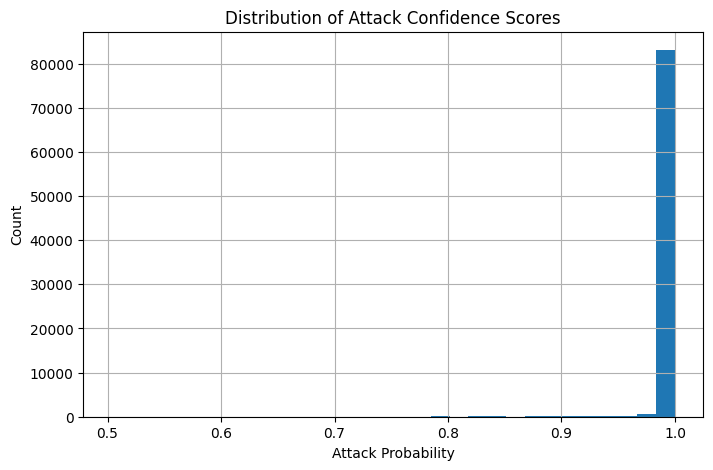

In [58]:
attack_preds = alerts_df[alerts_df["Predicted_Label"] == 1]

plt.figure(figsize=(8, 5))
plt.hist(attack_preds["Attack_Probability"], bins=30)
plt.xlabel("Attack Probability")
plt.ylabel("Count")
plt.title("Distribution of Attack Confidence Scores")
plt.grid(True)
plt.show()

## Concept Drift Simulation
Real network traffic does not stay the same over time.  
A model that performs well on one portion of the dataset may perform worse later if traffic patterns change.

This section simulates concept drift by evaluating the model on different parts of the dataset instead of relying only on a random split.

### Prepare Ordered Dataset
To simulate changing traffic behavior, the dataset is divided into sequential chunks.
If a timestamp column exists, the data is sorted by time. Otherwise, the existing row order is used as an approximation.

In [59]:
drift_df = df.copy()

timestamp_col = None
for col in drift_df.columns:
    if str(col).strip().lower() in ["timestamp", "time", "flow start time"]:
        timestamp_col = col
        break

if timestamp_col is not None:
    drift_df[timestamp_col] = pd.to_datetime(drift_df[timestamp_col], errors="coerce")
    drift_df = drift_df.sort_values(by=timestamp_col).reset_index(drop=True)
    print("Using timestamp column for drift simulation:", timestamp_col)
else:
    drift_df = drift_df.reset_index(drop=True)
    print("No timestamp column found. Using current row order for drift simulation.")

No timestamp column found. Using current row order for drift simulation.


### Build Sequential Chunks
The dataset is split into several sequential parts.  
This allows the model to be trained on earlier traffic and tested on later traffic.

In [60]:
NUM_CHUNKS = 5

chunk_size = len(drift_df) // NUM_CHUNKS
drift_chunks = []

for i in range(NUM_CHUNKS):
    start_idx = i * chunk_size
    end_idx = (i + 1) * chunk_size if i < NUM_CHUNKS - 1 else len(drift_df)
    chunk = drift_df.iloc[start_idx:end_idx].copy()
    drift_chunks.append(chunk)

for i, chunk in enumerate(drift_chunks, start=1):
    print(f"Chunk {i}: {chunk.shape}")

Chunk 1: (504159, 79)
Chunk 2: (504159, 79)
Chunk 3: (504159, 79)
Chunk 4: (504159, 79)
Chunk 5: (504162, 79)


### Train on Early Chunk and Test on Later Chunks
A model is trained on the earliest chunk and then tested on later chunks to see whether performance drops over time.

In [61]:
from sklearn.base import clone

target_col = "Label"
feature_cols = [col for col in drift_df.columns if col != target_col]

train_chunk = drift_chunks[0].copy()
X_train_drift = train_chunk[feature_cols]
y_train_drift = train_chunk[target_col]

rf_drift_model = clone(rf_model)
rf_drift_model.fit(X_train_drift, y_train_drift)

print("Drift model trained on Chunk 1")

Drift model trained on Chunk 1


### Evaluate Drift Across Chunks
This compares how the same trained model performs as the test data moves farther away from the training data.

In [62]:
drift_results = []

for i in range(1, NUM_CHUNKS):

    test_chunk = drift_chunks[i].copy()

    X_test_drift = test_chunk[feature_cols]
    y_test_drift = test_chunk[target_col]

    y_pred_drift = rf_drift_model.predict(X_test_drift)
    y_score_drift = rf_drift_model.predict_proba(X_test_drift)[:, 1]

    drift_accuracy = accuracy_score(y_test_drift, y_pred_drift)
    drift_precision = precision_score(y_test_drift, y_pred_drift, zero_division=0)
    drift_recall = recall_score(y_test_drift, y_pred_drift, zero_division=0)
    drift_f1 = f1_score(y_test_drift, y_pred_drift, zero_division=0)

    if len(np.unique(y_test_drift)) > 1:
        drift_roc_auc = roc_auc_score(y_test_drift, y_score_drift)
        drift_pr_auc = average_precision_score(y_test_drift, y_score_drift)
    else:
        drift_roc_auc = np.nan
        drift_pr_auc = np.nan

    drift_results.append({
        "Train_Chunk": 1,
        "Test_Chunk": i + 1,
        "Accuracy": drift_accuracy,
        "Precision": drift_precision,
        "Recall": drift_recall,
        "F1-Score": drift_f1,
        "ROC-AUC": drift_roc_auc,
        "PR-AUC": drift_pr_auc
    })

drift_results_df = pd.DataFrame(drift_results)
drift_results_df.round(4)

,Train_Chunk,Test_Chunk,Accuracy,Precision,Recall,F1-Score,ROC-AUC,PR-AUC
0,1,2,0.9973,0.8398,0.3188,0.4622,0.8370,0.4929
1,1,3,0.9666,0.0096,0.0661,0.0168,0.8977,0.0302
2,1,4,0.9292,0.5714,0.0001,0.0002,0.9045,0.7554
3,1,5,0.6731,0.9917,0.0143,0.0283,0.9939,0.9893


### Plot Drift Results
These plots show whether performance stays stable or drops as the traffic changes.

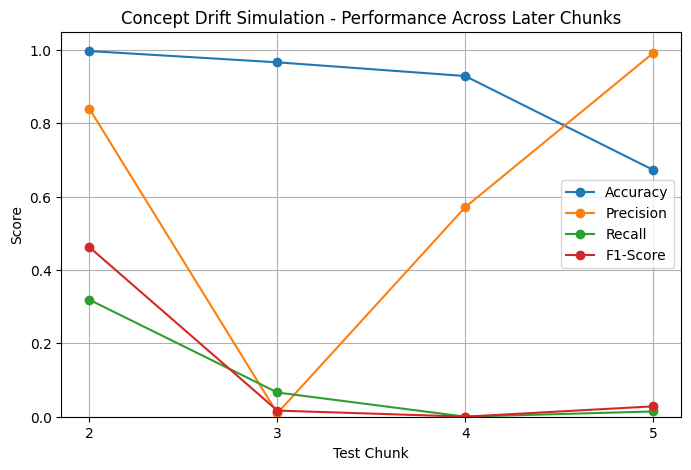

In [63]:
plt.figure(figsize=(8, 5))
plt.plot(drift_results_df["Test_Chunk"], drift_results_df["Accuracy"], marker="o", label="Accuracy")
plt.plot(drift_results_df["Test_Chunk"], drift_results_df["Precision"], marker="o", label="Precision")
plt.plot(drift_results_df["Test_Chunk"], drift_results_df["Recall"], marker="o", label="Recall")
plt.plot(drift_results_df["Test_Chunk"], drift_results_df["F1-Score"], marker="o", label="F1-Score")

plt.xlabel("Test Chunk")
plt.ylabel("Score")
plt.title("Concept Drift Simulation - Performance Across Later Chunks")
plt.ylim(0, 1.05)
plt.xticks(drift_results_df["Test_Chunk"])
plt.grid(True)
plt.legend()
plt.show()

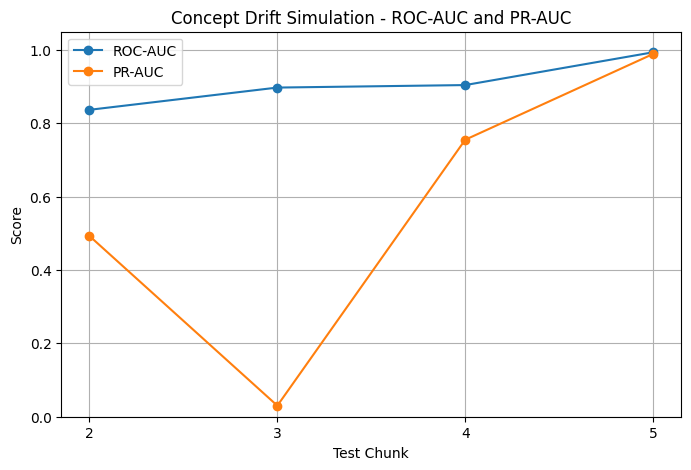

In [64]:
plt.figure(figsize=(8, 5))
plt.plot(drift_results_df["Test_Chunk"], drift_results_df["ROC-AUC"], marker="o", label="ROC-AUC")
plt.plot(drift_results_df["Test_Chunk"], drift_results_df["PR-AUC"], marker="o", label="PR-AUC")

plt.xlabel("Test Chunk")
plt.ylabel("Score")
plt.title("Concept Drift Simulation - ROC-AUC and PR-AUC")
plt.ylim(0, 1.05)
plt.xticks(drift_results_df["Test_Chunk"])
plt.grid(True)
plt.legend()
plt.show()

### Compare Class Balance Across Chunks
If the label distribution changes over time, that can also affect model performance.

In [65]:
chunk_balance = []

for i, chunk in enumerate(drift_chunks, start=1):
    counts = chunk[target_col].value_counts(normalize=True).to_dict()
    chunk_balance.append({
        "Chunk": i,
        "Benign_Ratio": counts.get(0, 0),
        "Attack_Ratio": counts.get(1, 0)
    })

chunk_balance_df = pd.DataFrame(chunk_balance)
chunk_balance_df.round(4)

,Chunk,Benign_Ratio,Attack_Ratio
0,1,0.5660,0.4340
1,2,0.9963,0.0037
2,3,0.9957,0.0043
3,4,0.9292,0.0708
4,5,0.6684,0.3316


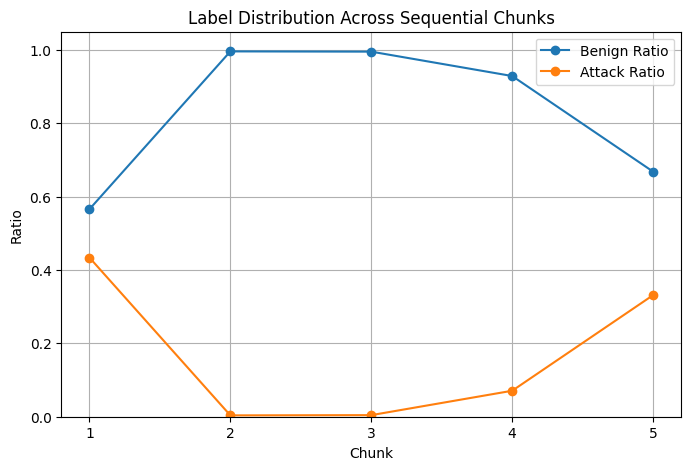

In [66]:
plt.figure(figsize=(8, 5))
plt.plot(chunk_balance_df["Chunk"], chunk_balance_df["Benign_Ratio"], marker="o", label="Benign Ratio")
plt.plot(chunk_balance_df["Chunk"], chunk_balance_df["Attack_Ratio"], marker="o", label="Attack Ratio")

plt.xlabel("Chunk")
plt.ylabel("Ratio")
plt.title("Label Distribution Across Sequential Chunks")
plt.ylim(0, 1.05)
plt.xticks(chunk_balance_df["Chunk"])
plt.grid(True)
plt.legend()
plt.show()

In [67]:
drift_output_path = os.path.join(BASE_PATH, "results", "concept_drift_results.csv")
os.makedirs(os.path.dirname(drift_output_path), exist_ok=True)

drift_results_df.to_csv(drift_output_path, index=False)
print("Concept drift results saved to:", drift_output_path)

Concept drift results saved to: /home/phillip/IDS_Project/results/concept_drift_results.csv


In [68]:
# =============================
# Save artifacts for Streamlit
# =============================

import os
import joblib
import numpy as np
import pandas as pd

BASE_PATH = "/home/phillip/IDS_Project"

os.makedirs(f"{BASE_PATH}/models", exist_ok=True)
os.makedirs(f"{BASE_PATH}/results", exist_ok=True)
os.makedirs(f"{BASE_PATH}/artifacts", exist_ok=True)

# -------------------
# Make sure y_test is a pandas Series
# -------------------
if isinstance(y_test, np.ndarray):
    y_test = pd.Series(y_test, index=X_test.index)

# -------------------
# Save trained models
# -------------------
joblib.dump(rf_model, f"{BASE_PATH}/models/random_forest_model.pkl")
joblib.dump(log_model, f"{BASE_PATH}/models/logistic_regression_model.pkl")
joblib.dump(scaler, f"{BASE_PATH}/models/standard_scaler.pkl")

print("Models saved")

# -------------------
# Save comparison table
# -------------------
results_df = pd.DataFrame(results)

results_df.to_csv(
    f"{BASE_PATH}/results/model_comparison.csv",
    index=False
)

print("Model comparison saved")

# -------------------
# Save feature importance
# -------------------
feature_importance_df = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
})

feature_importance_df = feature_importance_df.sort_values(
    "Importance",
    ascending=False
)

feature_importance_df.to_csv(
    f"{BASE_PATH}/results/feature_importance.csv",
    index=False
)

print("Feature importance saved")

# -------------------
# Save sample test data
# -------------------
sample_size = min(5000, len(X_test))
X_test_sample = X_test.sample(sample_size, random_state=42)
y_test_sample = y_test.loc[X_test_sample.index]

X_test_sample.to_csv(
    f"{BASE_PATH}/artifacts/X_test_sample.csv",
    index=False
)

y_test_sample.to_csv(
    f"{BASE_PATH}/artifacts/y_test_sample.csv",
    index=False
)

print("Test sample saved")

# -------------------
# Generate alerts
# -------------------
probs = rf_model.predict_proba(X_test_sample)[:, 1]

alerts_df = X_test_sample.copy()
alerts_df["Attack_Probability"] = probs
alerts_df["Predicted_Label"] = (probs > 0.90).astype(int)
alerts_df["Predicted_Label_Name"] = alerts_df["Predicted_Label"].map({
    0: "BENIGN",
    1: "ATTACK"
})

alerts_df.to_csv(
    f"{BASE_PATH}/results/high_confidence_alerts.csv",
    index=False
)

print("Alerts saved")

# -------------------
# Simple concept drift simulation
# -------------------
drift_results = []

chunk_indices = np.array_split(X_test.index.to_numpy(), 5)

for i, idx in enumerate(chunk_indices):
    chunk_X = X_test.loc[idx]
    chunk_y = y_test.loc[idx]

    preds = rf_model.predict(chunk_X)
    probs = rf_model.predict_proba(chunk_X)[:, 1]

    drift_results.append({
        "Test_Chunk": i,
        "Accuracy": accuracy_score(chunk_y, preds),
        "Precision": precision_score(chunk_y, preds, zero_division=0),
        "Recall": recall_score(chunk_y, preds, zero_division=0),
        "F1-Score": f1_score(chunk_y, preds, zero_division=0),
        "ROC-AUC": roc_auc_score(chunk_y, probs),
        "PR-AUC": average_precision_score(chunk_y, probs)
    })

drift_df = pd.DataFrame(drift_results)

drift_df.to_csv(
    f"{BASE_PATH}/results/concept_drift_results.csv",
    index=False
)

print("Concept drift results saved")
print("All files exported for Streamlit")

Models saved
Model comparison saved
Feature importance saved
Test sample saved
Alerts saved
Concept drift results saved
All files exported for Streamlit
